<a href="https://colab.research.google.com/github/AaravJain626/ML-DL-using-PyTorch/blob/main/torch_WorkFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.10.0+cpu'

##**1.Data(preparing and loading)**

we will be usig *linear regression formula* to create some known data

the linear regression formula will make a straight line with *known* **parameters**

In [2]:
#Create known parameters 34
weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X =  torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X),len(y)

(50, 50)

##Spilitting data into training and test sets(imp)
create training dataset AND test set

In [4]:
# create a train/test split
train_split = int(0.8 * len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [5]:
#using matplotlib to plot the data for visualization
def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None
                    ):
# plots training data,test data and compares predictions

  plt.figure(figsize=(10, 10))
  plt.scatter(train_data, train_labels,c="b",s=4,label="Training Data")

  plt.scatter(test_data,test_labels,c="g",s=10,label="Testing Data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")
    plt.legend(prop={"size":14});


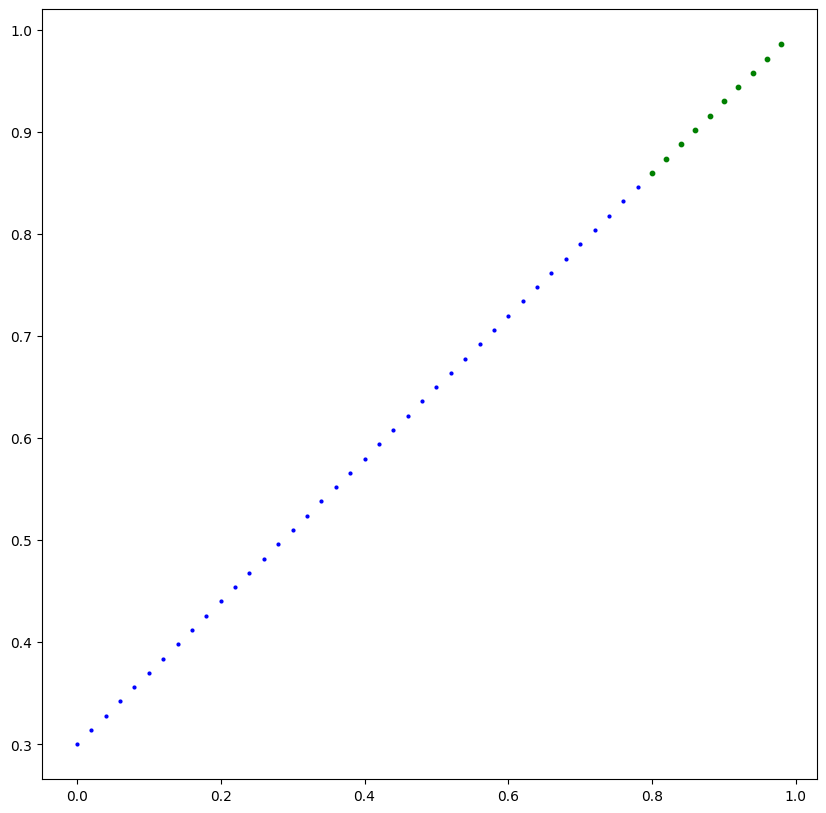

In [6]:
plot_prediction()

##2.Building model
first PyTorch model


In [7]:
from torch import nn
class LinearRegressionModel(nn.Module):#->building brick of PyTorch NNs
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                               requires_grad=True,
                                               dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    # forward method to define the computation in the model
    def forward(self,x: torch.Tensor): #>torch.Tensor
        return self.weights * x + self.bias

###Checking the contents of our PyTorch model
we can check params of our model by using `.parameters().`

In [8]:
#create a random seed
torch.manual_seed(42)

#create and instance of the model(this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
# list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

###Making predictions using `torch.inference_mode()`

To check model's predictive power,we will se how well it predicts `y_test` based on `x_test`

In [10]:
# Making predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)
  print(y_preds)
  # we can also do the same thing with
  # torch.no_grad():


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


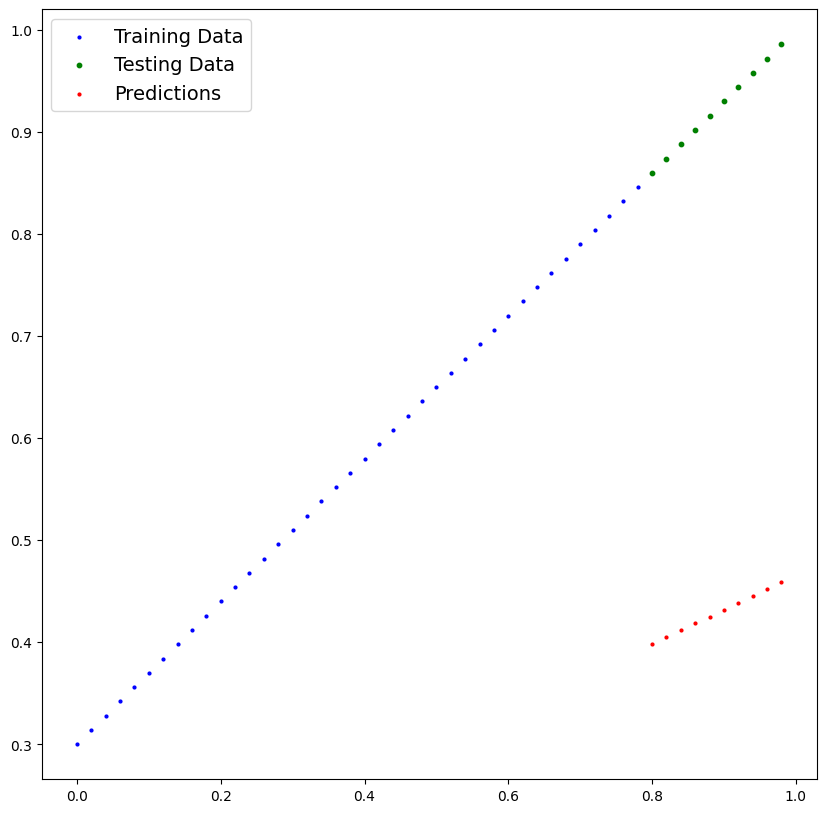

In [11]:
plot_prediction(predictions=y_preds)

In [12]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

###3.Training our model

**giving known parameters**
*A way to measure how wrong the models predictions are is to is use the loss function*

***note:_** Loss function may also be called cost function or criterion in different areas.*

In [13]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:
model_0.state_dict()#check out our model's params(a value that the model  sets itself )

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [15]:
#Setup a loss function
loss_fn = nn.L1Loss()

#Setup an Optimizer(stochastic gradient descent)
optimizer = torch.optim.SGD( params=model_0.parameters(),
                            lr=0.01)#lr = learning rate,Important Hyperparameter



In [16]:
loss_fn

L1Loss()

###buiilding a training loop and testing loop in PyTorch

Things that we need in training loop:

* Loop through the data

* Forward pass:(involves data moving through model's`forward()` functions)-also called forward propagation

* calculate the loss (compare forward pass predictions to ground truth labels)

* Optimizer zero grad
                
* Loss backward - moves backward throgh the network to calculate the gradients of each param of model w.r.t loss(Backpropagation)
                
* Optimizer step: use the optimzer to adjust model's parameters to try and improve the loss(gradient descent)

In [17]:
#epoch is a loop through the data(hyperparameter)
epochs = 200
epoch_count = []
loss_values = []
test_loss_values =[]
#Training
#Loop through the data
for epoch in range(epochs):
  #set the model to training mode
  model_0.train() #Train mode sets all parameters that require gradients to require gradient

  #forward pass
  y_pred = model_0(X_train)

  #calculate the loss

  loss = loss_fn(y_pred,y_train)
  print(f"Loss:{loss}")

  #Optimzer zero grad
  optimizer.zero_grad()

  #perform Backpropagation w.r.t to parameters of the model
  loss.backward()

  #step the optimzer
  optimizer.step()
  model_0.eval() #turns of gradient tracking
  #turns of different settings in the model not needed for evaluation/testing (dropout/Batch norm layers)
  with torch.inference_mode(): #turns of gradient tracking etc.
  #do the forward pass
   test_pred = model_0(X_test)
   #Calculating the loss
   if epoch % 10 == 0:
    test_loss = loss_fn(test_pred , y_test)
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
  # Print out what's happening

  print(f"Epoch:{epoch}|loss:{loss}|Test Loss:{test_loss}")

#print out model_0.state_dict()
model_0.state_dict()


Loss:0.31288138031959534
Epoch:0|loss:0.31288138031959534|Test Loss:0.48106518387794495
Loss:0.3013603389263153
Epoch:1|loss:0.3013603389263153|Test Loss:0.48106518387794495
Loss:0.28983935713768005
Epoch:2|loss:0.28983935713768005|Test Loss:0.48106518387794495
Loss:0.2783183455467224
Epoch:3|loss:0.2783183455467224|Test Loss:0.48106518387794495
Loss:0.26679736375808716
Epoch:4|loss:0.26679736375808716|Test Loss:0.48106518387794495
Loss:0.2552763521671295
Epoch:5|loss:0.2552763521671295|Test Loss:0.48106518387794495
Loss:0.24375534057617188
Epoch:6|loss:0.24375534057617188|Test Loss:0.48106518387794495
Loss:0.23223432898521423
Epoch:7|loss:0.23223432898521423|Test Loss:0.48106518387794495
Loss:0.22071333229541779
Epoch:8|loss:0.22071333229541779|Test Loss:0.48106518387794495
Loss:0.20919232070446014
Epoch:9|loss:0.20919232070446014|Test Loss:0.48106518387794495
Loss:0.1976713240146637
Epoch:10|loss:0.1976713240146637|Test Loss:0.3463551998138428
Loss:0.18615034222602844
Epoch:11|loss:0

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [18]:
import numpy as np
np.array(torch.tensor(loss_values).numpy),test_loss_values

/tmp/ipykernel_313/628028437.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  np.array(torch.tensor(loss_values).numpy),test_loss_values


(array(<built-in method numpy of Tensor object at 0x79cb07749950>,
       dtype=object),
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647),
  tensor(0.0565),
  tensor(0.0482),
  tensor(0.0406),
  tensor(0.0323),
  tensor(0.0241),
  tensor(0.0165),
  tensor(0.0082),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050)])

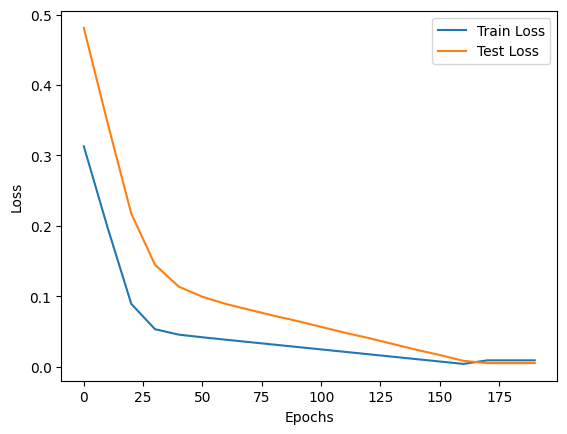

In [19]:
with torch.no_grad():
  # Convert list of tensors to a list of Python numbers for plotting
  train_losses_plot = [loss.item() for loss in loss_values]
  test_losses_plot = [loss.item() for loss in test_loss_values]

  plt.plot(epoch_count ,train_losses_plot,label="Train Loss")
  plt.plot(epoch_count, test_losses_plot,label="Test Loss")
  plt.ylabel("Loss")
  plt.xlabel("Epochs")
  plt.legend()

In [20]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [21]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

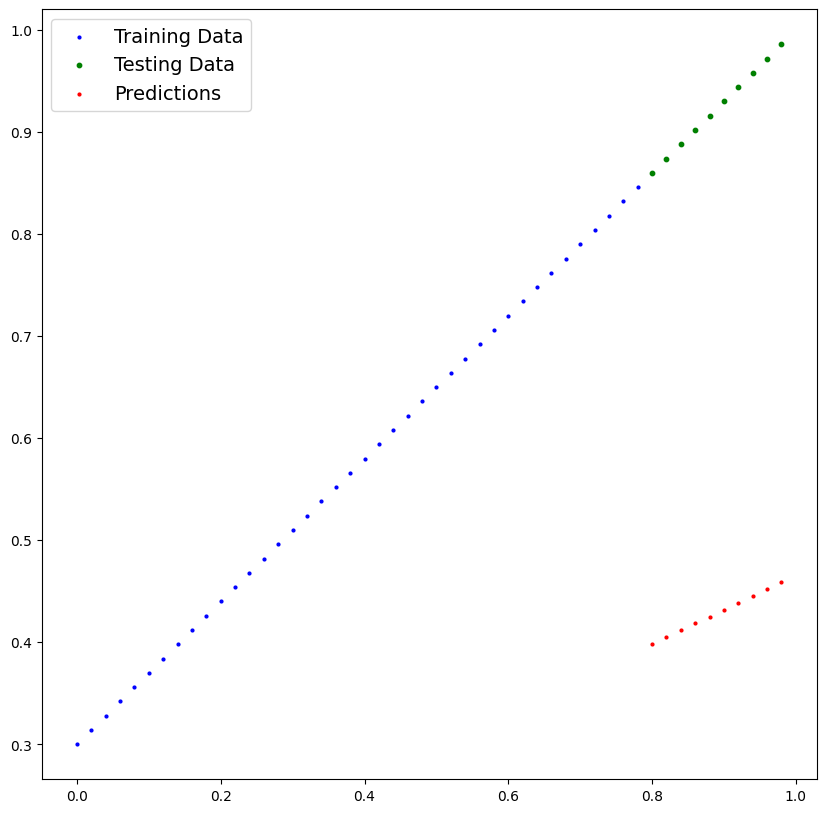

In [22]:
plot_prediction(predictions=y_preds)

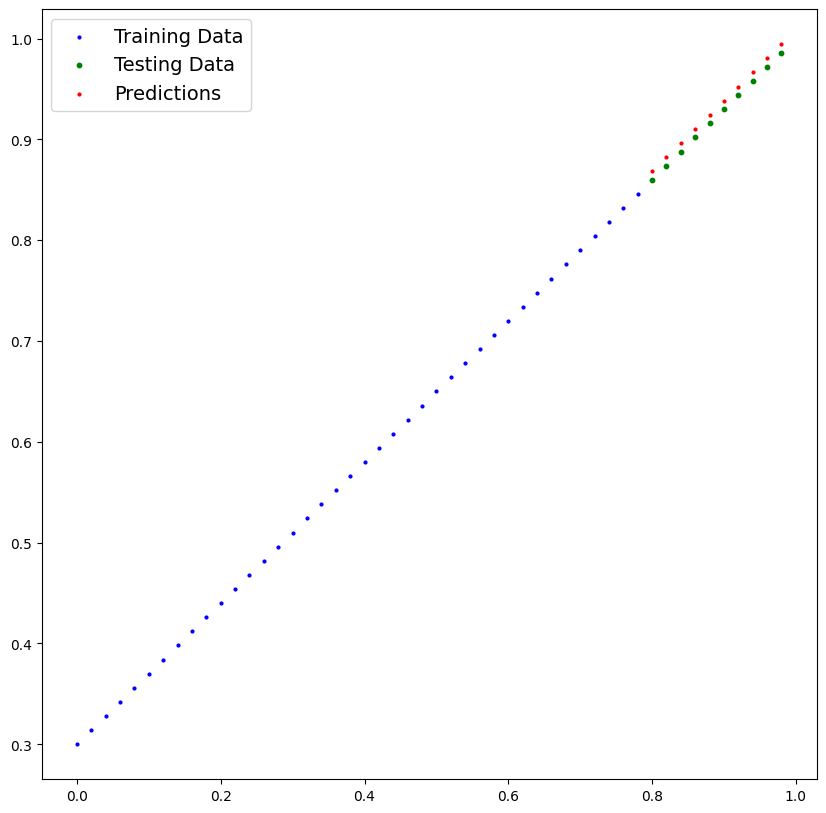

In [23]:
plot_prediction(predictions=y_preds_new)

## Saving a model in PyTorch
3 main methods for saving and loading models in PyTorch:

* `torch.save()` = Helps save a PyTorch object in Python pickle format.

* `torch.load()` = Allows us to load a saved Python Object

* `torch.nn.Module.load_state_dict()` = this allows to load a model's saved state dictionary

In [31]:
#Saving our pytorch model
from pathlib import Path

#Create model's directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

#2. Making model save path

MODEL_NAME = "First_model_AJ.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
MODEL_SAVE_PATH

#Saving model to state_dict


torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)
print("Saving model to:",MODEL_SAVE_PATH)

Saving model to: models/First_model_AJ.pth


##LOADING A PYTORCH MODEL


In [32]:
torch.load(MODEL_SAVE_PATH)

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [33]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [36]:
#New instance of the model class
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [37]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])